### Mithil Agneya
### 5/11/26
### Analysis and Questions


#### Importing required libaries and reading CSV into notebook

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Cleaned_EV_Data.csv')

#### Q1: Based on range, is the drivable range increasing each model year?

##### To answer this, I grouped the data by `model_year` and calculated the average `electric_range_cleaned`. A line plot seemed to be the most appropriate visualization to show trends over time.

In [13]:
range_tred = df.groupby('model_year')['electric_range_cleaned'].mean().reset_index()
range_tred

,model_year,electric_range_cleaned
0,1999,74.000000
1,2000,58.000000
2,2002,95.000000
3,2003,95.000000
4,2008,221.315789
5,2010,231.190476
6,2011,71.815009
7,2012,60.311859
8,2013,77.316811
9,2014,77.951135


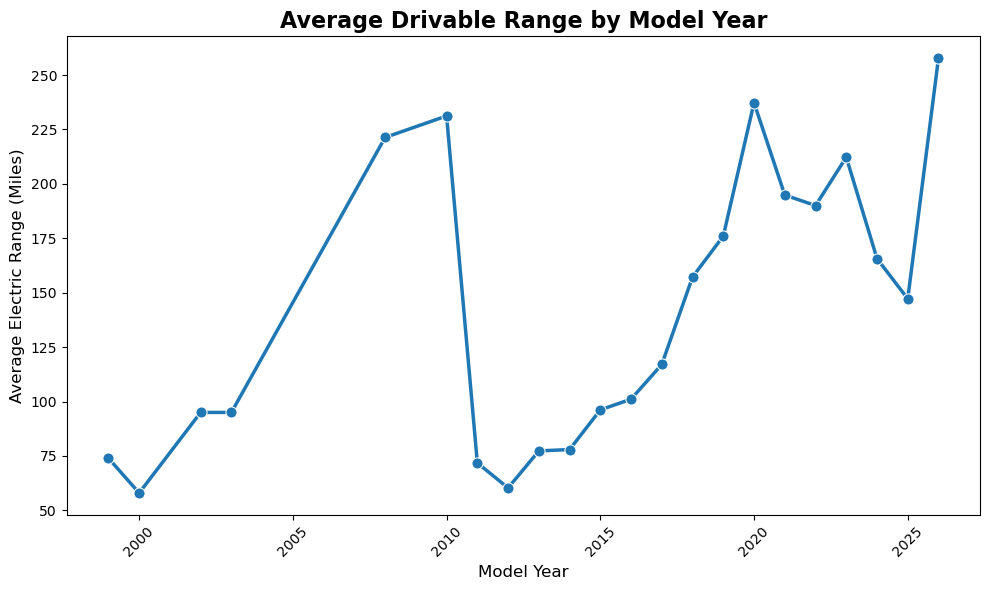

In [14]:
plt.figure(figsize=(10,6))
sns.lineplot(data=range_tred, x='model_year', y='electric_range_cleaned',marker='o',linewidth=2.5,markersize=8)

plt.title('Average Drivable Range by Model Year', fontsize=16, fontweight='bold')
plt.xlabel('Model Year', fontsize=12)
plt.ylabel('Average Electric Range (Miles)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

#### As we can see, there seems to be two peaks at which EV's range was at a high, one around 2009, and another this year. However, there is a steady incline in the range of an Electric Vehicle, with about a 25 mile increase in range each model year.

#### Q2: What is the market split between pure electric cars and hybrid vehicles?

#### I determined the overall market distribution by calculating the value counts of the 'vehicle_type' column. A pie chart should provide a clear, proportional view of this split.

In [15]:
market_split = df['vehicle_type'].value_counts()
market_split

vehicle_type
EV        147969
Hybrid     55707
Name: count, dtype: int64

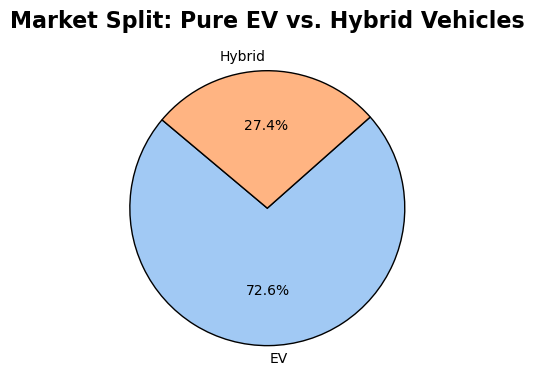

In [16]:
plt.figure(figsize=(4, 4))
plt.pie(market_split, 
        labels=market_split.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=sns.color_palette("pastel")[0:2], 
        wedgeprops={'edgecolor': 'black', 'linewidth': 1})

plt.title('Market Split: Pure EV vs. Hybrid Vehicles', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.show()

#### As we can see, almost 3/4 of the market is dominated by EVs, with 72.6% of the total car population. Hybrids make up around 28% of the total electrified vehicle population.

#### Q3: How old is the average EV by make as compared to the average Hybrid by make?


#### To prevent the chart from becoming cluttered, I isolated the top 10 most popular car makes in the dataset. Then, created a pivot table to compare the average age of EVs versus Hybrids side-by-side using a grouped bar chart.

In [17]:
top_10_makes = df['make'].value_counts().head(10).index
df_top_makes = df[df['make'].isin(top_10_makes)]

age_comparison = pd.pivot_table(df_top_makes, 
                                values='age', 
                                index='make', 
                                columns='vehicle_type', 
                                aggfunc='mean')
age_comparison

vehicle_type,EV,Hybrid
make,,
BMW,8.005155,4.052526
CHEVROLET,5.352793,9.570041
CHRYSLER,NaN,3.397666
FORD,10.931193,7.784208
JEEP,NaN,1.694626
KIA,3.605256,1.880102
NISSAN,7.215349,NaN
TESLA,2.723360,NaN
TOYOTA,12.129630,3.856760


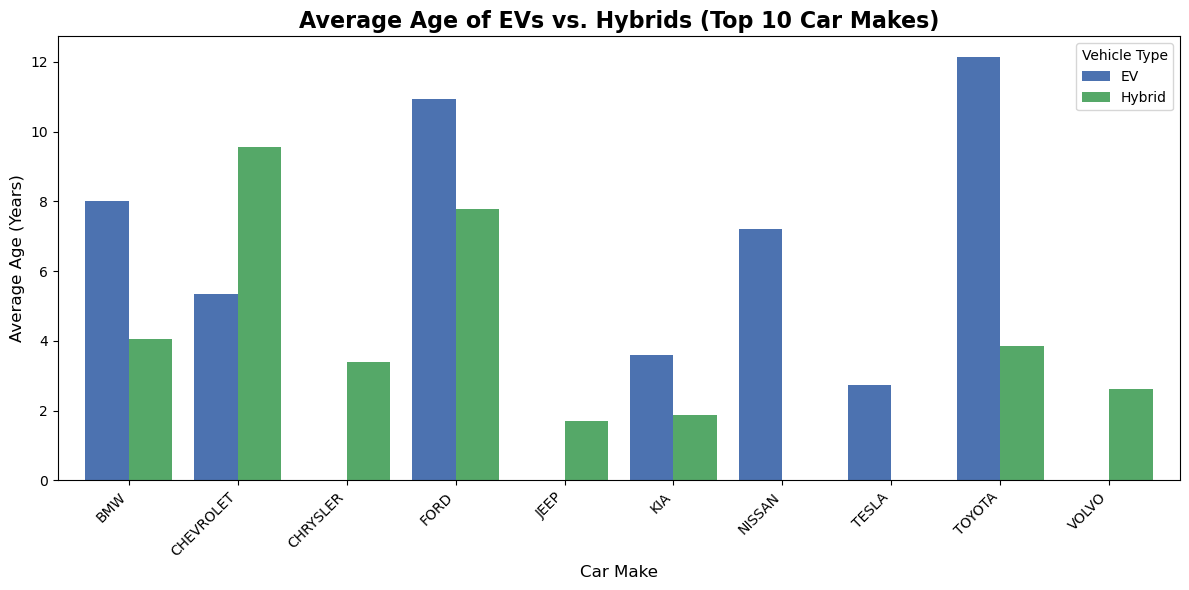

In [18]:
ax = age_comparison.plot(kind='bar', figsize=(12, 6), width=0.8, color=['#4C72B0', '#55A868'])

plt.title('Average Age of EVs vs. Hybrids (Top 10 Car Makes)', fontsize=16, fontweight='bold')
plt.xlabel('Car Make', fontsize=12)
plt.ylabel('Average Age (Years)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Vehicle Type', fontsize=10)
plt.tight_layout()

plt.show()

#### Analyzing the graph, it seems that in the state of Washington, EVs on average are older than hybrid vehicles. This surprises me, as hybrid vehicles have been mainstream for longer than full EVs have. Regardless, of the companies that do offer EV vehicles, the EVs are much older compared to hybrids. 

#### Q4: Which car brands have the biggest market share in high-population (Urban) counties compared to rural ones?


#### To answer this, I calculated the percentage of total vehicles each brand represented within `Urban` and `Rural` areas. To keep the visualization readable, I focused on the top 10 most popular brands overall and compared their market penetration in both environments using a grouped bar chart.

In [19]:
top_10_brands = df['make'].value_counts().head(10).index
df_top_brands = df[df['make'].isin(top_10_brands)]

area_totals = df.groupby('area_type').size().reset_index(name='total_vehicles')

brand_area_counts = df_top_brands.groupby(['area_type', 'make']).size().reset_index(name='brand_count')

market_share_df = pd.merge(brand_area_counts, area_totals, on='area_type')
market_share_df['market_share_pct'] = (market_share_df['brand_count'] / market_share_df['total_vehicles']) * 100

pivot_market_share = market_share_df.pivot(index='make', columns='area_type', values='market_share_pct').fillna(0)

pivot_market_share = pivot_market_share.sort_values(by='Urban', ascending=False)

pivot_market_share

area_type,Rural,Urban
make,,
TESLA,46.574516,56.304565
NISSAN,7.218474,6.569603
CHEVROLET,9.703253,5.700342
TOYOTA,8.244199,4.447680
KIA,3.735396,3.927849
BMW,3.055236,3.524495
JEEP,4.821458,3.068295
VOLVO,1.925292,2.414732
FORD,2.907136,1.928335


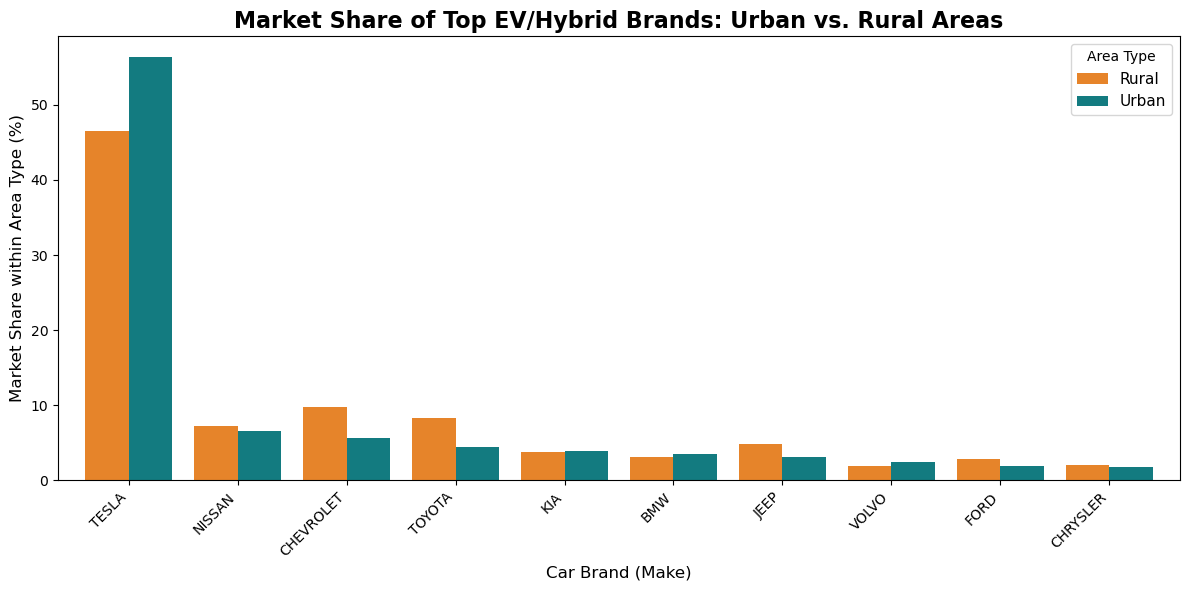

In [20]:
ax = pivot_market_share.plot(kind='bar', figsize=(12, 6), width=0.8, color=['#E6842A', '#137B80'])

plt.title('Market Share of Top EV/Hybrid Brands: Urban vs. Rural Areas', fontsize=16, fontweight='bold')
plt.xlabel('Car Brand (Make)', fontsize=12)
plt.ylabel('Market Share within Area Type (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Area Type', fontsize=11)
plt.tight_layout()

# Display the plot
plt.show()

#### As we can see, Tesla is the single biggest EV brand in both ubran and rural areas. It proves they make quality cars,with Nissan and Chevrolet claiming 2nd and 3rd place.